# Gold-Set v2 — passagen-genaue Labels (n ≥ 30–50)

**Warum?** Das bisherige Gold-Set (`eval/gold_dracula.jsonl`, n=21) labelt auf **Kapitel-Ebene**.
Das hat zwei gemessene Probleme:

1. Ein Kapitel deckt viele Chunks ab → ein „Hit" ist billig, die Metrik überschätzt das Retrieval
   (und unterbewertet den passagen-genauen Reranker — Befund aus Exp 3).
2. n=21 ist zu klein für signifikante Vergleiche (Befund aus Exp 2: 4:4-Bilanz, keine Aussage möglich).

**Design-Entscheidung — Span-Labels statt Chunk-IDs:** Ein Label ist ein Textbereich
`{book_id, char_start, char_end}` im bereinigten Buchtext. Ein Retrieval-Treffer liegt vor, wenn ein
gefundener Chunk einen Gold-Span **überlappt**. Vorteil: Chunk-Indizes verschieben sich beim Re-Chunking
(andere `target_chars`), Zeichen-Offsets im bereinigten Text nicht. Damit bleibt das Gold-Set gültig,
wenn wir später am Chunking schrauben — genau das wollen wir ja messen können.

**Voraussetzungen:** `make up` (Qdrant :6333, Backend :8001) und Host-Ollama (für die Such-Helfer).

**Start:**
```bash
cd ~/LLM/book-RAG
uv run --with jupyterlab --with pandas --with matplotlib --with plotly --with nbformat \
  --with scikit-learn --with wordcloud jupyter lab notebooks/gold_set_v2.ipynb
```

*(Läuft der Kernel stattdessen aus dem Projekt-`.venv`, dort einmalig
`uv pip install nbformat` — Plotly braucht es fürs Rendern im Notebook.)*


In [1]:
import json
import random
import urllib.request

import pandas as pd

QDRANT_URL = "http://localhost:6333"
OLLAMA_URL = "http://localhost:11434"
COLLECTION = "book_chunks"
EMBED_MODEL = "bge-m3"

GROUP_ID = "Horror"          # Zielgruppe fuer diesen Durchgang (GoT = zweiter Durchgang)
K = 10                        # Kandidaten pro Such-Vorschau
SEED = 42                     # Reproduzierbare Stichproben

GOLD_V1_PATH = "../eval/gold_dracula.jsonl"
GOLD_V2_PATH = "../eval/gold_v2.jsonl"

pd.set_option("display.max_colwidth", 100)


def _post(url: str, body: dict) -> dict:
    req = urllib.request.Request(
        url, data=json.dumps(body).encode(), headers={"Content-Type": "application/json"}
    )
    return json.load(urllib.request.urlopen(req))


## 1. Bestandsaufnahme: alle Chunks der Gruppe laden

Wir lesen die Chunks direkt aus Qdrant (`scroll`, ohne Vektoren) — dieselben Daten, auf denen
die App sucht. Das DataFrame ist unsere Arbeitsgrundlage für Stichproben und Labeling.


In [2]:
def load_chunks(group_id: str) -> pd.DataFrame:
    rows, offset = [], None
    while True:
        body = {
            "limit": 256, "offset": offset, "with_payload": True, "with_vector": False,
            "filter": {"must": [{"key": "group_id", "match": {"value": group_id}}]},
        }
        res = _post(f"{QDRANT_URL}/collections/{COLLECTION}/points/scroll", body)["result"]
        for p in res["points"]:
            pl = p["payload"]
            rows.append({
                "book_id": pl["book_id"], "book_title": pl.get("book_title"),
                "chapter": pl.get("chapter"), "chunk_index": pl["chunk_index"],
                "char_start": pl["char_start"], "char_end": pl["char_end"],
                "n_chars": pl["char_end"] - pl["char_start"], "text": pl["text"],
            })
        offset = res.get("next_page_offset")
        if offset is None:
            break
    return pd.DataFrame(rows).sort_values(["book_id", "chunk_index"]).reset_index(drop=True)


chunks = load_chunks(GROUP_ID)
print(f"{len(chunks)} Chunks in Gruppe '{GROUP_ID}'")
chunks[["book_title", "chapter", "chunk_index", "char_start", "char_end", "n_chars"]].head()


581 Chunks in Gruppe 'Horror'


,book_title,chapter,chunk_index,char_start,char_end,n_chars
0,Dracula,NaN,0,0,1791,1791
1,Dracula,CHAPTER I,1,1804,3956,2152
2,Dracula,CHAPTER I,2,3022,5627,2605
3,Dracula,CHAPTER I,3,4634,7239,2605
4,Dracula,CHAPTER I,4,5629,7777,2148


In [3]:
# Verteilung: Chunks pro Kapitel — zeigt, wie grob ein Kapitel-Label ist.
per_chapter = chunks.groupby("chapter", dropna=False).size().rename("n_chunks")
print(per_chapter.describe().round(1))
per_chapter.sort_values(ascending=False).head(10)


count    28.0
mean     20.8
std       5.2
min       1.0
25%      20.0
50%      21.0
75%      23.0
max      32.0
Name: n_chunks, dtype: float64


chapter
CHAPTER XXVII    32
CHAPTER XXVI     26
CHAPTER XVIII    24
CHAPTER XII      24
CHAPTER XIII     24
CHAPTER XIV      24
CHAPTER IX       23
CHAPTER XXV      23
CHAPTER X        23
CHAPTER XX       22
Name: n_chunks, dtype: int64

### Bedeutungsraum-Karte: interaktive PCA der Chunk-Embeddings

Die 1024-dimensionalen bge-m3-Vektoren werden per PCA auf 2D projiziert — **Hover zeigt
Kapitel + Textanfang**, so siehst du, welche Chunks im Bedeutungsraum zusammenliegen.
Die Farbe kodiert die Position im Buch: bilden frühe und späte Kapitel eigene Regionen?
Zusätzlich werden die 21 v1-Fragen eingebettet und als Rauten eingezeichnet — landet eine
Frage nicht in der Nähe „ihrer" Kapitel-Chunks, ist sie ein Kandidat für die bekannten
Retrieval-Misses (d01/d09!).

*Ehrliche Einordnung:* 2 Komponenten erklären bei 1024 Dimensionen nur einen kleinen Teil
der Varianz (steht über dem Plot) — Distanzen hier sind ein grobes Schattenbild, kein Beweis.
Fürs Hypothesen-Bilden („was gehört zusammen?") reicht es.


In [19]:
import numpy as np
import plotly.express as px
from sklearn.decomposition import PCA


def load_vectors(group_id: str) -> tuple[np.ndarray, pd.DataFrame]:
    """Vektoren + Metadaten aller Chunks der Gruppe (Reihenfolge konsistent)."""
    vecs, rows, offset = [], [], None
    while True:
        body = {
            "limit": 256, "offset": offset, "with_payload": True, "with_vector": True,
            "filter": {"must": [{"key": "group_id", "match": {"value": group_id}}]},
        }
        res = _post(f"{QDRANT_URL}/collections/{COLLECTION}/points/scroll", body)["result"]
        for p in res["points"]:
            pl = p["payload"]
            vecs.append(p["vector"])
            rows.append({"chapter": pl.get("chapter") or "(vor Kap. 1)",
                         "chunk_index": pl["chunk_index"],
                         "preview": pl["text"][:110].replace("\n", " ") + " …"})
        offset = res.get("next_page_offset")
        if offset is None:
            break
    return np.asarray(vecs, dtype=np.float32), pd.DataFrame(rows)


vecs, meta = load_vectors(GROUP_ID)
pca = PCA(n_components=2, random_state=SEED).fit(vecs)
xy = pca.transform(vecs)
meta[["x", "y"]] = xy
evr = pca.explained_variance_ratio_

# v1-Fragen in denselben Raum projizieren (ein Batch-Embedding-Call).
gold_v1 = [json.loads(l) for l in open(GOLD_V1_PATH, encoding="utf-8") if l.strip()]
q_texts = [g["question"] for g in gold_v1]
q_emb = np.asarray(
    _post(f"{OLLAMA_URL}/api/embed", {"model": EMBED_MODEL, "input": q_texts})["embeddings"],
    dtype=np.float32,
)
q_emb /= np.linalg.norm(q_emb, axis=1, keepdims=True)  # L2 wie im Retriever
q_xy = pca.transform(q_emb)
q_df = pd.DataFrame({"x": q_xy[:, 0], "y": q_xy[:, 1],
                     "id": [g["id"] for g in gold_v1], "frage": q_texts})

fig = px.scatter(
    meta, x="x", y="y", color="chunk_index",
    color_continuous_scale="Blues", template="plotly_white",
    hover_data={"x": False, "y": False, "chapter": True, "chunk_index": True, "preview": True},
    title=(f"Chunks im Bedeutungsraum (PCA, erklärte Varianz "
           f"{evr[0]:.0%} + {evr[1]:.0%}) — Rauten = v1-Fragen"),
    labels={"chunk_index": "Position im Buch"},
)
fig.update_traces(marker={"size": 6, "line": {"width": 0.5, "color": "#52514e"}})
fig.add_scatter(
    x=q_df["x"], y=q_df["y"], mode="markers", name="v1-Fragen",
    marker={"symbol": "diamond", "size": 10, "color": "#e34948",
            "line": {"width": 1, "color": "#4a1b0c"}},
    customdata=q_df[["id", "frage"]],
    hovertemplate="%{customdata[0]}: %{customdata[1]}<extra></extra>",
)
fig.update_layout(width=880, height=560, xaxis_title="PC 1", yaxis_title="PC 2",
                  legend={"x": 0.01, "y": 0.99, "bgcolor": "rgba(255,255,255,0.6)"})
fig.show()


### Wortwolken: ein Gefühl für den Text

Häufigste Wörter (ohne englische Stoppwörter) — links der ganze Korpus der Gruppe, rechts
ein einzelnes Kapitel zum Vergleich (`WC_CHAPTER` anpassen). Nützlich als Plausibilitäts-Check
fürs Labeln: Kapitel mit auffälligem eigenem Vokabular sind gute Kandidaten für trennscharfe
Fragen. (Für deutsche Texte die Stoppwortliste tauschen.)


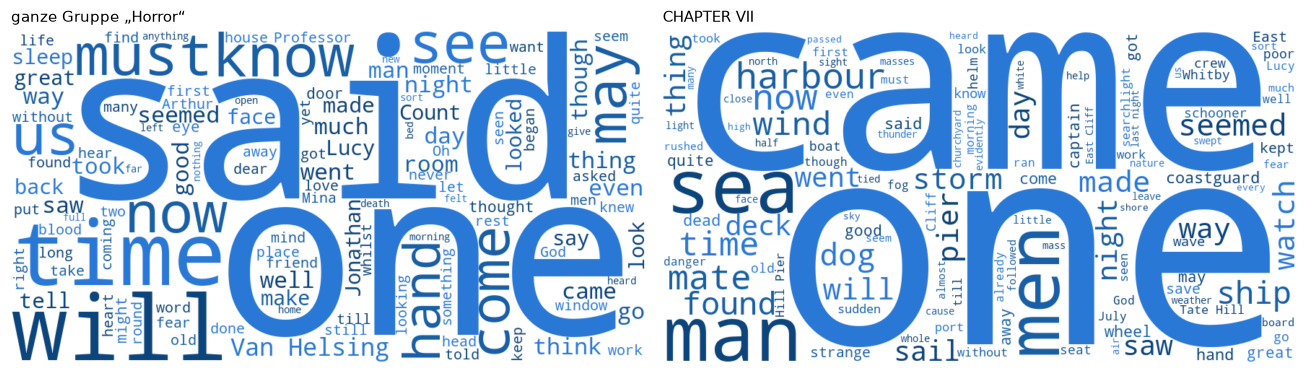

In [20]:
import matplotlib.pyplot as plt
from wordcloud import STOPWORDS, WordCloud

WC_CHAPTER = "CHAPTER VII"  # Kapitel fuer die rechte Wolke

_BLUES = ["#2a78d6", "#185fa5", "#0c447c"]


def make_wc(text: str) -> WordCloud:
    return WordCloud(
        width=880, height=460, background_color="white", stopwords=STOPWORDS,
        max_words=120, random_state=SEED,
        color_func=lambda *a, **k: k["random_state"].choice(_BLUES),
    ).generate(text)


fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), dpi=110, facecolor="white")
corpus = " ".join(chunks["text"])
kapitel = " ".join(chunks.loc[chunks["chapter"] == WC_CHAPTER, "text"])
for ax, (title, text) in zip(axes, [
    (f"ganze Gruppe „{GROUP_ID}“", corpus),
    (WC_CHAPTER, kapitel if kapitel.strip() else "leer"),
]):
    ax.imshow(make_wc(text), interpolation="bilinear")
    ax.set_title(title, fontsize=10, loc="left")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. Wie billig ist ein Kapitel-Hit? (Granularitäts-Problem quantifizieren)

Für jedes v1-Item zählen wir, wie viele Chunks seine `relevant_chapters` abdecken.
Deckt ein Label z. B. 40 Chunks ab, reicht irgendein Treffer aus 40, um als „Hit" zu zählen —
obwohl vielleicht nur 2 davon die Antwort wirklich enthalten.


In [6]:
import re

_ROMAN_RE = re.compile(r"CHAPTER\s+([IVXLCDM]+)", re.IGNORECASE)


def chapter_roman(chapter):
    if not isinstance(chapter, str):  # None/NaN (Chunks vor der ersten Ueberschrift)
        return None
    m = _ROMAN_RE.search(chapter)
    return m.group(1).upper() if m else None


gold_v1 = [json.loads(l) for l in open(GOLD_V1_PATH, encoding="utf-8") if l.strip()]
chunks["roman"] = chunks["chapter"].map(chapter_roman)

rows = []
for item in gold_v1:
    rel = {r.upper() for r in item["relevant_chapters"]}
    covered = int((chunks["roman"].isin(rel)).sum())
    rows.append({"id": item["id"], "kapitel": ",".join(sorted(rel)), "abgedeckte_chunks": covered})
coverage = pd.DataFrame(rows)
print(f"Ø abgedeckte Chunks pro Kapitel-Label: {coverage['abgedeckte_chunks'].mean():.1f}")
print(f"(bei {len(chunks)} Chunks gesamt — so viel 'Trefferfläche' schenkt ein Kapitel-Label)")
coverage


Ø abgedeckte Chunks pro Kapitel-Label: 30.2
(bei 581 Chunks gesamt — so viel 'Trefferfläche' schenkt ein Kapitel-Label)


,id,kapitel,abgedeckte_chunks
0,d01,"I,II",41
1,d02,III,18
2,d03,VII,21
3,d04,"VI,VIII",44
4,d05,"IX,X",46
5,d06,"X,XI,XII",65
6,d07,"XV,XVI",36
7,d08,XXVII,32
8,d09,"XII,XIII,XIV",72
9,d10,"XVII,XVIII",44


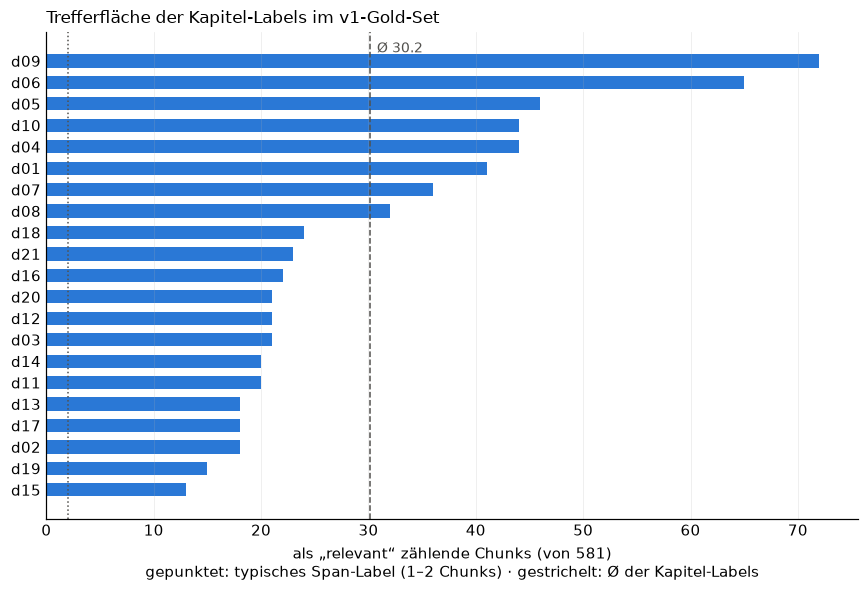

In [7]:
import matplotlib.pyplot as plt

COL_KAPITEL = "#2a78d6"   # Serie 1 (blau)
COL_SPAN = "#1baf7a"      # Serie 2 (aqua) — braucht direkte Wertelabels (Kontrast-Relief)


def _style_ax(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_facecolor("white")
    return ax


# Trefferflaeche pro v1-Item: wie viele Chunks zaehlen unter dem Kapitel-Label als Treffer?
cov = coverage.sort_values("abgedeckte_chunks")
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=110, facecolor="white")
_style_ax(ax)
ax.barh(cov["id"], cov["abgedeckte_chunks"], height=0.62, color=COL_KAPITEL)
mean_val = cov["abgedeckte_chunks"].mean()
ax.axvline(mean_val, color="#52514e", lw=1, ls="--")
ax.text(mean_val + 0.6, len(cov) - 0.6, f"Ø {mean_val:.1f}", color="#52514e", fontsize=9)
ax.axvline(2, color="#52514e", lw=1, ls=":")
ax.set_xlabel("als „relevant“ zählende Chunks (von 581)\n"
              "gepunktet: typisches Span-Label (1–2 Chunks) · gestrichelt: Ø der Kapitel-Labels")
ax.set_title("Trefferfläche der Kapitel-Labels im v1-Gold-Set", fontsize=11, loc="left")
ax.grid(axis="x", alpha=0.25)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()


## 3. Sampling-Strategie für neue Items

Ziel für diesen Durchgang (Gruppe Horror/Dracula): **von 21 auf ~35 Items**, danach derselbe
Workflow für GoT. Damit das Set nicht nur „leichte" Fragen enthält, mischen wir Fragetypen:

| Typ | Anteil | Beispiel |
|---|---|---|
| `fact` — direkte Faktenfrage | ~50 % | „Was geschieht mit der Demeter in Whitby?" |
| `paraphrase` — Frage nutzt andere Wörter als der Text | ~25 % | „Wie überwindet der Graf senkrechte Mauern?" |
| `multi` — Antwort verteilt über mehrere Stellen | ~15 % | „Welche Regeln gelten für Vampire?" |
| `unanswerable` — steht nicht im Buch (`spans: []`) | ~10 % | „Wie heißt Draculas Bruder?" |

`unanswerable`-Items messen, ob die Pipeline ehrlich bleibt („Dazu steht in den Quellen nichts") —
und ob das Retrieval bei solchen Fragen wenigstens nichts Hochkonfidentes zurückgibt.

Die Stichprobe unten zieht Chunks **stratifiziert über den Buchverlauf** (Anfang/Mitte/Ende),
damit die Fragen nicht alle aus den ersten Kapiteln kommen — lies einen Chunk, schreib eine Frage
dazu (in eigenen Worten!), und notiere dir seinen Bereich.


In [8]:
random.seed(SEED)
n_per_bucket = 4  # pro Drittel des Buchs

sample_rows = []
for name, part in chunks.groupby(pd.qcut(chunks["chunk_index"], 3, labels=["Anfang", "Mitte", "Ende"]), observed=True):
    picks = part.sample(n=min(n_per_bucket, len(part)), random_state=SEED)
    for _, r in picks.iterrows():
        sample_rows.append({"bucket": name, **r[["chapter", "chunk_index", "char_start", "char_end"]].to_dict(),
                            "preview": r["text"][:220].replace("\n", " ") + " …"})
pd.DataFrame(sample_rows)


,bucket,chapter,chunk_index,char_start,char_end,preview
0,Anfang,CHAPTER VIII,138,201414,205569,"* * * * * _11 August, 3 a. m._--Diary again. No sleep now, so I may as well write. I am too agi..."
1,Anfang,CHAPTER I,16,25008,27795,"""The night is chill, mein Herr, and my master the Count bade me take all care of you. There is a..."
2,Anfang,CHAPTER VIII,155,228438,230747,"_Later._--Glad I made the resolution; gladder that I kept to it. I had lain tossing about, and h..."
3,Anfang,CHAPTER VI,96,143017,145530,"""I wouldn't fash masel' about them, miss. Them things be all wore out. Mind, I don't say that th..."
4,Mitte,CHAPTER XII,239,347809,349621,"""Such a sad blow has befallen us. Mr. Hawkins has died very suddenly. Some may not think it so s..."
5,Mitte,CHAPTER XVII,331,481234,483186,"The crowd melted away, after the bustling fashion common to arrival platforms; and I was beginni..."
6,Mitte,CHAPTER XIV,270,392938,395044,MINA HARKER'S JOURNAL _23 September_.--Jonathan is better after a bad night. I am so glad that ...
7,Mitte,CHAPTER XVII,338,491464,493624,"""Let me write this all out now. We must be ready for Dr. Van Helsing when he comes. I have sent ..."
8,Ende,CHAPTER XXVI,525,763903,766248,"Early this morning we listened, with breathless anxiety, for her response in her trance. The hyp..."
9,Ende,CHAPTER XX,403,587085,589221,"""But I do mind,"" he answered. ""The affairs of their clients are absolutely safe in the hands of ..."


In [9]:
# Einen Kandidaten im Volltext lesen (chunk_index anpassen):
CHUNK_INDEX = int(chunks["chunk_index"].iloc[0])

row = chunks[chunks["chunk_index"] == CHUNK_INDEX].iloc[0]
print(f"{row['book_title']} — {row['chapter']}  (chunk {row['chunk_index']}, "
      f"Zeichen {row['char_start']}–{row['char_end']})\n")
print(row["text"])


Dracula — nan  (chunk 0, Zeichen 0–1791)

DRACULA

_by_

Bram Stoker

[Illustration: colophon]

NEW YORK

GROSSET & DUNLAP

_Publishers_

Copyright, 1897, in the United States of America, according to Act of Congress, by Bram Stoker

[_All rights reserved._]

PRINTED IN THE UNITED STATES AT THE COUNTRY LIFE PRESS, GARDEN CITY, N.Y.

TO

MY DEAR FRIEND

HOMMY-BEG

Contents

How these papers have been placed in sequence will be made manifest in the reading of them. All needless matters have been eliminated, so that a history almost at variance with the possibilities of later-day belief may stand forth as simple fact. There is throughout no statement of past things wherein memory may err, for all the records chosen are exactly contemporary, given from the standpoints and within the range of knowledge of those who made them.

DRACULA


### Optional: LLM-Entwürfe für Fragen (opt-in)

`qwen2.5` kann pro Chunk einen Frage-Entwurf liefern. **Zwei Regeln:** (1) Entwürfe sind nur
Rohmaterial — jede Frage wird manuell umformuliert und geprüft, sonst evaluieren wir später
das Modell gegen seine eigenen Formulierungen (Leakage: die Frage übernimmt Wortlaut aus dem
Chunk, und das dense Retrieval findet sie trivial). (2) Antwort immer selbst gegen den Chunk
verifizieren.


In [10]:
GENERATE_DRAFTS = False  # bewusst opt-in; Ollama muss laufen

def draft_question(chunk_text: str, model: str = "qwen2.5:7b-instruct-q4_K_M") -> str:
    body = {
        "model": model, "stream": False,
        "messages": [{
            "role": "user",
            "content": (
                "Formuliere EINE deutsche Quizfrage zu folgendem Romanausschnitt. "
                "Die Frage darf keine Formulierungen aus dem Text übernehmen und muss "
                "ohne den Text verständlich sein. Antworte NUR mit der Frage.\n\n" + chunk_text
            ),
        }],
    }
    return _post(f"{OLLAMA_URL}/api/chat", body)["message"]["content"].strip()


if GENERATE_DRAFTS:
    for s in sample_rows[:3]:
        row = chunks[chunks["chunk_index"] == s["chunk_index"]].iloc[0]
        print(f"chunk {s['chunk_index']} ({s['chapter']}):")
        print("  Entwurf:", draft_question(row["text"]), "\n")
else:
    print("GENERATE_DRAFTS=False — Zelle übersprungen.")


GENERATE_DRAFTS=False — Zelle übersprungen.


## 4. Labeling-Helfer: Frage → Kandidaten → Spans wählen

Der Kern des Workflows. Für eine (selbst geschriebene) Frage zeigt `preview_search` die Top-K
der **echten** Pipeline-Suche (bge-m3 + Cosine + Gruppenfilter). Daraus wählst du die Chunks,
die die Antwort wirklich enthalten, und übernimmst deren Zeichenbereiche als Gold-Spans.

**Wichtig wegen Chunk-Overlap:** Dieselbe Passage kann am Ende von Chunk *i* **und** am Anfang
von Chunk *i+1* stehen. Prüfe deshalb immer auch die Nachbar-Chunks (`show_neighbors`) und labe
die Passage, nicht den Chunk — im Zweifel beide überlappenden Bereiche als einen Span zusammenfassen.
Benachbarte/überlappende Spans werden beim Hinzufügen automatisch verschmolzen.


In [11]:
def _l2(v):
    s = sum(x * x for x in v) ** 0.5
    return [x / s for x in v] if s else v


def preview_search(question: str, k: int = K) -> pd.DataFrame:
    emb = _post(f"{OLLAMA_URL}/api/embed", {"model": EMBED_MODEL, "input": [question]})["embeddings"][0]
    body = {
        "query": _l2(emb), "limit": k, "with_payload": True,
        "filter": {"must": [{"key": "group_id", "match": {"value": GROUP_ID}}]},
    }
    pts = _post(f"{QDRANT_URL}/collections/{COLLECTION}/points/query", body)["result"]["points"]
    return pd.DataFrame([{
        "rank": i + 1, "score": round(p["score"], 3),
        "chapter": p["payload"].get("chapter"), "chunk_index": p["payload"]["chunk_index"],
        "char_start": p["payload"]["char_start"], "char_end": p["payload"]["char_end"],
        "preview": p["payload"]["text"][:160].replace("\n", " ") + " …",
    } for i, p in enumerate(pts)])


def show_neighbors(chunk_index: int, radius: int = 1) -> pd.DataFrame:
    sel = chunks[chunks["chunk_index"].between(chunk_index - radius, chunk_index + radius)]
    out = sel[["chapter", "chunk_index", "char_start", "char_end"]].copy()
    out["preview"] = sel["text"].str[:160].str.replace("\n", " ", regex=False) + " …"
    return out


preview_search("Warum reist Jonathan Harker nach Transsilvanien?")


,rank,score,chapter,chunk_index,char_start,char_end,preview
0,1,0.536,CHAPTER VIII,152,223398,225455,"""I write by desire of Mr. Jonathan Harker, who is himself not strong enough to write, though pro..."
1,2,0.529,CHAPTER XXVII,579,837821,839690,"In the summer of this year we made a journey to Transylvania, and went over the old ground which..."
2,3,0.527,CHAPTER XXIV,479,696049,698045,"DR. SEWARD'S PHONOGRAPH DIARY, SPOKEN BY VAN HELSING This to Jonathan Harker. You are to stay ..."
3,4,0.517,CHAPTER VIII,151,222314,224114,"_19 August._--Joy, joy, joy! although not all joy. At last, news of Jonathan. The dear fellow ha..."
4,5,0.515,CHAPTER IX,158,232138,234312,"_Letter, Mina Harker to Lucy Westenra._ ""_Buda-Pesth, 24 August._ ""My dearest Lucy,-- ""I know..."
5,6,0.506,CHAPTER XXIV,481,698047,701369,"VAN HELSING. _Jonathan Harker's Journal._ _4 October._--When I read to Mina, Van Helsing's mes..."
6,7,0.505,CHAPTER XIV,284,411313,413295,"""A thousand thanks for your kind letter, which has taken a great weight off my mind. And yet, if..."
7,8,0.504,CHAPTER XIV,283,409854,412065,"""Jonathan will be here at half-past eleven, and you must come to lunch with us and see him then;..."
8,9,0.502,CHAPTER XXVII,549,798377,800481,"MINA HARKER'S JOURNAL _1 November._--All day long we have travelled, and at a good speed. The h..."
9,10,0.499,CHAPTER II,32,47905,49735,"""We are in Transylvania; and Transylvania is not England. Our ways are not your ways, and there ..."


In [12]:
show_neighbors(2)

,chapter,chunk_index,char_start,char_end,preview
1,CHAPTER I,1,1804,3956,JONATHAN HARKER'S JOURNAL (_Kept in shorthand._) _3 May. Bistritz._--Left Munich at 8:35 P. M....
2,CHAPTER I,2,3022,5627,"Having had some time at my disposal when in London, I had visited the British Museum, and made s..."
3,CHAPTER I,3,4634,7239,"I did not sleep well, though my bed was comfortable enough, for I had all sorts of queer dreams...."


## 5. Gold-Items erfassen

`add_item` sammelt neue Items in `gold_v2` (in-memory) und validiert:
eindeutige ID, Spans innerhalb des Buchs, Antwort nicht leer. Benachbarte oder überlappende
Spans werden automatisch zu einem verschmolzen. `spans=[]` ist nur für `qtype="unanswerable"` erlaubt.


In [13]:
gold_v2: list[dict] = []

_book_extent = chunks.groupby("book_id")["char_end"].max().to_dict()
_default_book = chunks["book_id"].iloc[0]


def _merge_spans(spans: list[tuple[int, int]]) -> list[dict]:
    merged: list[list[int]] = []
    for start, end in sorted(spans):
        if merged and start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])
    return [{"char_start": s, "char_end": e} for s, e in merged]


def add_item(item_id: str, question: str, answer: str, spans: list[tuple[int, int]],
             qtype: str = "fact", chapters: list[str] | None = None,
             book_id: str | None = None, question_en: str = "", note: str = "",
             source: str = "manual") -> None:
    assert qtype in {"fact", "paraphrase", "multi", "unanswerable"}, f"unbekannter qtype: {qtype}"
    assert item_id not in {g["id"] for g in gold_v2}, f"ID {item_id} existiert schon"
    assert question.strip() and answer.strip(), "Frage/Antwort darf nicht leer sein"
    book = book_id or _default_book
    if qtype == "unanswerable":
        assert not spans, "unanswerable-Items haben keine Spans"
    else:
        assert spans, "mindestens ein Span noetig (oder qtype='unanswerable')"
        extent = _book_extent[book]
        for s, e in spans:
            assert 0 <= s < e <= extent, f"Span ({s},{e}) ausserhalb des Buchs (0..{extent})"
    gold_v2.append({
        "id": item_id, "question": question.strip(), "question_en": question_en.strip(),
        "answer": answer.strip(), "book_id": book, "spans": _merge_spans(spans),
        "qtype": qtype, "chapters": chapters or [], "note": note, "source": source,
    })
    print(f"ok — {len(gold_v2)} Items erfasst")


# Beispiel-Workflow (an d01 angelehnt): Frage suchen, Kandidat MANUELL pruefen
# (Volltext lesen!), dann dessen Bereich als Span uebernehmen.
_demo_q = "Aus welchem Grund faehrt der junge Anwalt zu Beginn nach Osteuropa?"
_demo_top = preview_search(_demo_q).iloc[0]  # hier: Rank 1 nach Sichtung als korrekt bestaetigt

add_item(
    "v2_demo",
    question=_demo_q,
    answer="Er soll fuer Graf Dracula den Kauf eines Anwesens in England (Carfax) abwickeln.",
    spans=[(int(_demo_top["char_start"]), int(_demo_top["char_end"]))],
    qtype="paraphrase", chapters=["I", "II"], source="manual",
)
gold_v2[-1]


ok — 1 Items erfasst


{'id': 'v2_demo',
 'question': 'Aus welchem Grund faehrt der junge Anwalt zu Beginn nach Osteuropa?',
 'question_en': '',
 'answer': 'Er soll fuer Graf Dracula den Kauf eines Anwesens in England (Carfax) abwickeln.',
 'book_id': '96bbfd4a64b749df99d584d98e1bc210',
 'spans': [{'char_start': 699759, 'char_end': 703288}],
 'qtype': 'paraphrase',
 'chapters': ['I', 'II'],
 'note': '',
 'source': 'manual'}

## 6. v1-Items übernehmen (Spans nachtragen)

Die 21 bestehenden Items bleiben wertvoll — sie brauchen nur Spans. Workflow pro Item:
Zelle unten zeigt die Suche für das v1-Item plus alle Chunks seiner Gold-Kapitel;
daraus die tatsächlich antwort-tragenden Bereiche als Spans in `V1_SPANS` eintragen.
(Chapters übernehmen wir mit — so bleibt die alte Metrik zum Vergleich berechenbar.)


In [14]:
V1_INDEX = 0  # 0..20: welches v1-Item gerade gelabelt wird

item = gold_v1[V1_INDEX]
print(json.dumps(item, ensure_ascii=False, indent=2))
print("\n— Top-Kandidaten der Suche: —")
display(preview_search(item["question"]))
rel = {r.upper() for r in item["relevant_chapters"]}
print("— alle Chunks der Gold-Kapitel: —")
sel = chunks[chunks["roman"].isin(rel)]
out = sel[["chapter", "chunk_index", "char_start", "char_end"]].copy()
out["preview"] = sel["text"].str[:120].str.replace("\n", " ", regex=False) + " …"
out


{
  "id": "d01",
  "question": "Warum reist Jonathan Harker nach Transsilvanien?",
  "question_en": "Why does Jonathan Harker travel to Transylvania?",
  "relevant_chapters": [
    "I",
    "II"
  ],
  "answer": "Harker reist geschaeftlich nach Transsilvanien, um als Anwalt Graf Draculas Immobilienkauf in England (Carfax) abzuwickeln.",
  "note": "Immobiliengeschaeft fuer Graf Dracula"
}

— Top-Kandidaten der Suche: —


,rank,score,chapter,chunk_index,char_start,char_end,preview
0,1,0.536,CHAPTER VIII,152,223398,225455,"""I write by desire of Mr. Jonathan Harker, who is himself not strong enough to write, though pro..."
1,2,0.529,CHAPTER XXVII,579,837821,839690,"In the summer of this year we made a journey to Transylvania, and went over the old ground which..."
2,3,0.527,CHAPTER XXIV,479,696049,698045,"DR. SEWARD'S PHONOGRAPH DIARY, SPOKEN BY VAN HELSING This to Jonathan Harker. You are to stay ..."
3,4,0.517,CHAPTER VIII,151,222314,224114,"_19 August._--Joy, joy, joy! although not all joy. At last, news of Jonathan. The dear fellow ha..."
4,5,0.515,CHAPTER IX,158,232138,234312,"_Letter, Mina Harker to Lucy Westenra._ ""_Buda-Pesth, 24 August._ ""My dearest Lucy,-- ""I know..."
5,6,0.506,CHAPTER XXIV,481,698047,701369,"VAN HELSING. _Jonathan Harker's Journal._ _4 October._--When I read to Mina, Van Helsing's mes..."
6,7,0.505,CHAPTER XIV,284,411313,413295,"""A thousand thanks for your kind letter, which has taken a great weight off my mind. And yet, if..."
7,8,0.504,CHAPTER XIV,283,409854,412065,"""Jonathan will be here at half-past eleven, and you must come to lunch with us and see him then;..."
8,9,0.502,CHAPTER XXVII,549,798377,800481,"MINA HARKER'S JOURNAL _1 November._--All day long we have travelled, and at a good speed. The h..."
9,10,0.499,CHAPTER II,32,47905,49735,"""We are in Transylvania; and Transylvania is not England. Our ways are not your ways, and there ..."


— alle Chunks der Gold-Kapitel: —


,chapter,chunk_index,char_start,char_end,preview
1,CHAPTER I,1,1804,3956,JONATHAN HARKER'S JOURNAL (_Kept in shorthand._) _3 May. Bistritz._--Left Munich at 8:35 P. M....
2,CHAPTER I,2,3022,5627,"Having had some time at my disposal when in London, I had visited the British Museum, and made s..."
3,CHAPTER I,3,4634,7239,"I did not sleep well, though my bed was comfortable enough, for I had all sorts of queer dreams...."
4,CHAPTER I,4,5629,7777,All day long we seemed to dawdle through a country which was full of beauty of every kind. Somet...
5,CHAPTER I,5,7241,9777,"It was on the dark side of twilight when we got to Bistritz, which is a very interesting old pla..."
6,CHAPTER I,6,8871,12044,"_4 May._--I found that my landlord had got a letter from the Count, directing him to secure the ..."
7,CHAPTER I,7,10482,12896,"""It is the eve of St. George's Day. Do you not know that to-night, when the clock strikes midnig..."
8,CHAPTER I,8,12057,14824,"_5 May. The Castle._--The grey of the morning has passed, and the sun is high over the distant h..."
9,CHAPTER I,9,13761,16369,"When we started, the crowd round the inn door, which had by this time swelled to a considerable ..."
10,CHAPTER I,10,14826,17248,I soon lost sight and recollection of ghostly fears in the beauty of the scene as we drove along...


In [15]:
# Nach dem Sichten: Spans je v1-ID hier sammeln und dann ueberfuehren, z. B.
# V1_SPANS = {"d01": [(0, 1903), (5211, 7100)], "d02": [(31000, 32900)]}
V1_SPANS: dict[str, list[tuple[int, int]]] = {}

for item in gold_v1:
    if item["id"] in V1_SPANS and item["id"] not in {g["id"] for g in gold_v2}:
        add_item(item["id"], item["question"], item["answer"], V1_SPANS[item["id"]],
                 qtype="fact", chapters=item["relevant_chapters"],
                 question_en=item.get("question_en", ""), note=item.get("note", ""), source="v1")
print(f"{len(V1_SPANS)} v1-Items mit Spans versehen.")


0 v1-Items mit Spans versehen.


## 7. Smoke-Eval: so rechnet die neue Metrik

Span-basierte Hit-Rate@k und MRR über die bisher erfassten Items: ein Treffer ist ein
gefundener Chunk desselben Buchs, dessen Bereich einen Gold-Span überlappt.
`unanswerable`-Items sind hier ausgenommen (für sie zählt später die Antwort-Ehrlichkeit,
nicht das Retrieval).


In [16]:
def span_hit(point_row: dict, item: dict) -> bool:
    if point_row.get("book_id") not in (None, item["book_id"]):
        return False
    return any(point_row["char_start"] < s["char_end"] and s["char_start"] < point_row["char_end"]
               for s in item["spans"])


def smoke_eval(items: list[dict], k: int = 8) -> pd.DataFrame:
    rows = []
    for item in items:
        if item["qtype"] == "unanswerable":
            continue
        cands = preview_search(item["question"], k=k)
        hits = [r + 1 for r, c in cands.iterrows() if span_hit(c.to_dict(), item)]
        rows.append({"id": item["id"], "qtype": item["qtype"],
                     "erster_hit_rank": hits[0] if hits else None,
                     "hit@1": bool(hits and hits[0] == 1), f"hit@{k}": bool(hits),
                     "rr": 1 / hits[0] if hits else 0.0})
    df = pd.DataFrame(rows)
    if len(df):
        print(f"Hit-Rate@1: {df['hit@1'].mean():.2f}   Hit-Rate@{k}: {df[f'hit@{k}'].mean():.2f}   "
              f"MRR: {df['rr'].mean():.3f}   (n={len(df)})")
    return df


smoke_eval(gold_v2)


Hit-Rate@1: 1.00   Hit-Rate@8: 1.00   MRR: 1.000   (n=1)


,id,qtype,erster_hit_rank,hit@1,hit@8,rr
0,v2_demo,paraphrase,1,True,True,1.0


### Grafik: Vorher/Nachher — Kapitel- vs. Span-Metrik auf denselben Fragen

Der eigentliche Punkt des v2-Sets, als paarweiser Vergleich: für jedes Item, das **beide**
Label-Arten trägt (Kapitel aus v1, Spans aus v2), werten wir **dieselben** Suchergebnisse
zweimal aus. Erwartung: die Kapitel-Metrik fällt systematisch zu gnädig aus — die Differenz
der Balken ist genau die Überschätzung, die wir loswerden wollen. (Aussagekräftig ab ~20
gelabelten Items; mit wenigen Items ist es nur eine Illustration.)


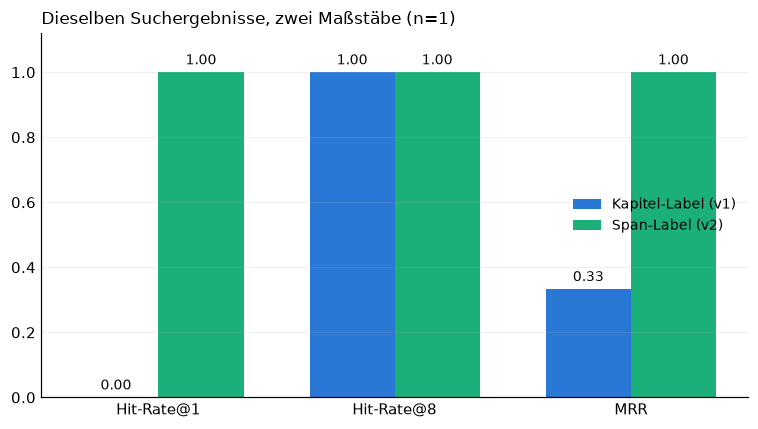

In [17]:
def paired_metrics(items: list[dict], k: int = 8) -> pd.DataFrame | None:
    eligible = [i for i in items if i["qtype"] != "unanswerable" and i["chapters"] and i["spans"]]
    if not eligible:
        print("Noch keine Items mit Kapitel- UND Span-Labels erfasst.")
        return None
    rows = []
    for item in eligible:
        cands = preview_search(item["question"], k=k)
        rel = {r.upper() for r in item["chapters"]}
        ch_hits = [r + 1 for r, c in cands.iterrows() if chapter_roman(c["chapter"]) in rel]
        sp_hits = [r + 1 for r, c in cands.iterrows() if span_hit(c.to_dict(), item)]
        rows.append({
            "kap_h1": bool(ch_hits and ch_hits[0] == 1), "kap_hk": bool(ch_hits),
            "kap_rr": 1 / ch_hits[0] if ch_hits else 0.0,
            "spa_h1": bool(sp_hits and sp_hits[0] == 1), "spa_hk": bool(sp_hits),
            "spa_rr": 1 / sp_hits[0] if sp_hits else 0.0,
        })
    df = pd.DataFrame(rows)
    return pd.DataFrame({
        "Kapitel-Label (v1)": [df["kap_h1"].mean(), df["kap_hk"].mean(), df["kap_rr"].mean()],
        "Span-Label (v2)": [df["spa_h1"].mean(), df["spa_hk"].mean(), df["spa_rr"].mean()],
    }, index=["Hit-Rate@1", "Hit-Rate@8", "MRR"])


paired = paired_metrics(gold_v2)
if paired is not None:
    n_items = len([i for i in gold_v2 if i["qtype"] != "unanswerable" and i["chapters"] and i["spans"]])
    x = range(len(paired.index))
    w = 0.36
    fig, ax = plt.subplots(figsize=(7, 4), dpi=110, facecolor="white")
    _style_ax(ax)
    b1 = ax.bar([i - w / 2 for i in x], paired["Kapitel-Label (v1)"], width=w,
                color=COL_KAPITEL, label="Kapitel-Label (v1)")
    b2 = ax.bar([i + w / 2 for i in x], paired["Span-Label (v2)"], width=w,
                color=COL_SPAN, label="Span-Label (v2)")
    for bars in (b1, b2):
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9, color="#0b0b0b")
    ax.set_xticks(list(x), paired.index)
    ax.set_ylim(0, 1.12)
    ax.set_title(f"Dieselben Suchergebnisse, zwei Maßstäbe (n={n_items})", fontsize=11, loc="left")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(length=0)
    ax.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()


## 8. Export

Schreibt `eval/gold_v2.jsonl` (ein Item pro Zeile). `SAVE=True` setzen, wenn der Stand
gesichert werden soll — die Zelle überschreibt eine bestehende Datei **nicht**, sondern
verweigert dann mit Hinweis (bewusst, damit kein kuratierter Stand verloren geht;
alte Datei vorher umbenennen oder Pfad ändern).

## Nächster Schritt (außerhalb dieses Notebooks)

`eval/retrieval_eval.py` bekommt einen `--gold-v2`-Modus: gleiche Retrieve-Schleife, Hit =
Span-Overlap statt Kapitel-Match (Funktion `span_hit` oben lässt sich 1:1 übernehmen). Die
Kapitel-Metrik bleibt als Vergleich erhalten — dann sehen wir schwarz auf weiß, wie stark
Kapitel-Labels das Retrieval überschätzt haben, und `answer_eval.py`/Reranker-Experimente
laufen ab dann gegen das faire Set.


In [18]:
import os

SAVE = False

if SAVE:
    assert gold_v2, "nichts zu exportieren"
    assert not os.path.exists(GOLD_V2_PATH), f"{GOLD_V2_PATH} existiert schon — erst umbenennen."
    with open(GOLD_V2_PATH, "w", encoding="utf-8") as f:
        for item in gold_v2:
            f.write(json.dumps(item, ensure_ascii=False) + "\n")
    print(f"{len(gold_v2)} Items → {GOLD_V2_PATH}")
else:
    print(f"SAVE=False — {len(gold_v2)} Items im Speicher, nichts geschrieben.")


SAVE=False — 1 Items im Speicher, nichts geschrieben.
